# Pseudo-Hessian preconditioner — Overthrust (implicit FWI)

Reproduces the **Overthrust** example from *Implicit full waveform inversion with
energy-weighted gradient* on the **sweep** acoustic solver (`impl='c'`, boundary-saving
`'bs'` mode). The only dependency is `sweep` plus the small self-contained helpers in
[`../src/ifwi_sweep.py`](../src/ifwi_sweep.py) — SIREN and the pseudo-Hessian
preconditioner are implemented there (no sweep-nn / sweep-opt / tinycudann).

1. **Conventional FWI** — optimize the grid velocity directly.
2. **Implicit FWI** — velocity reparameterized by a SIREN network, no preconditioning.
3. **Implicit FWI + pseudo-Hessian** — the velocity-grid gradient is weighted by
   `1 / sqrt(source · receiver illumination)` (read off the sweep solver) before being
   back-propagated into the network.

> Reference: *Implicit full waveform inversion with energy-weighted gradient.*
> DOI: [10.3997/2214-4609.202510069](https://doi.org/10.3997/2214-4609.202510069)

The config cell ships with `SMOKE = False` (the full 500-iteration run); set `SMOKE = True` for a quick check.

## Setup: models, acquisition, solver and observed data

In [1]:
import os

In [2]:
# ---------------- Overthrust / pseudo-Hessian configuration ----------------
MODEL_NAME  = "Overthrust"
MODEL       = "overthrust"               # velocity models embedded in src/models.py (no .npy files)
DH, DT      = 25.0, 0.002
SPATIAL_ORDER, ABCN = 8, 20              # paper: 8th-order space, 2nd-order time
NT, FM, DELAY = 1500, 8.0, 0.3            # 3.0 s Ricker, fm=8 Hz
SRC_INTERVAL, REC_INTERVAL = 4, 1        # sources every 100 m, receivers every 25 m (all surface points)
BATCH = 8
OMEGA, HIDDEN = 30.0, 128
CONV_LR = 20.0                            # paper: conventional FWI Adam lr = 20
NN_LR, LR_DECAY = 1e-4, 0.9995           # paper: IFWI Adam lr = 1e-4, exponential decay

# exp 2: implicit FWI (SIREN);  exp 3: + pseudo-Hessian (energy-weighted gradient)
STD2, LAYERS2 = 400.0, 6                  # paper: v_std = 400 (std of true-init), 6 hidden layers
STD3, LAYERS3 = 400.0, 6
HASH_CFG  = None
USE_PH    = True
GRAD_CLIP_Q = 0.005                       # stabilizer (NOT in paper): clip PH gradient at [0.5%,99.5%] quantiles; set 0 for the strict baseline
EXP3_TITLE = "implicit FWI + pseudo-Hessian (energy-weighted gradient)"
EXP3_LABEL = "iFWI + pseudo-Hessian"
TAG = "overthrust"

SMOKE = False                            # True = quick check; False = full paper run (use a GPU)
EPOCHS = int(os.environ.get("IFWI_EPOCHS", "0")) or (60 if SMOKE else 500)
CONV_EPOCHS = min(300, EPOCHS)           # conventional FWI diverges past ~300 iters at 8th order (paper shows FWI @ 300)

In [3]:
import os, sys, time
import numpy as np, torch, matplotlib.pyplot as plt
sys.path.insert(0, os.path.abspath("../src"))
import ifwi_sweep as F
import models

dev = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(F.SEED); np.random.seed(F.SEED)
print("device:", dev, torch.cuda.get_device_name(0) if dev == "cuda" else "")

vp_true   = getattr(models, MODEL)("true")      # velocity models embedded in src/models.py
vp_smooth = getattr(models, MODEL)("smooth")
shape = vp_true.shape; nz, nx = shape
vp_true_t   = torch.tensor(vp_true,   device=dev)
vp_smooth_t = torch.tensor(vp_smooth, device=dev)
print(f"{MODEL_NAME}: shape={shape}, dh={DH} m, vp in [{vp_true.min():.0f}, {vp_true.max():.0f}] m/s")

wavelet = F.ricker(NT, DT, FM, DELAY)
sources, receivers = F.survey(nx, SRC_INTERVAL, rec_interval=REC_INTERVAL)
print(f"{len(sources)} shots, {receivers.shape[1]} receivers, nt={NT}, epochs={EPOCHS}")

solver = F.make_solver(shape, DH, DT, spatial_order=SPATIAL_ORDER, abcn=ABCN, device=dev)
print("solver impl =", solver.impl, "(boundary-saving 'bs' mode used in every forward call)")

t0 = time.time()
observed = F.generate_observed(solver, wavelet, sources, receivers, vp_true_t)
print(f"observed data {tuple(observed.shape)} generated in {time.time()-t0:.1f}s")

device: cuda NVIDIA RTX 6000 Ada Generation


Overthrust: shape=(187, 401), dh=25.0 m, vp in [2529, 6000] m/s
101 shots, 401 receivers, nt=1500, epochs=500


solver impl = c (boundary-saving 'bs' mode used in every forward call)


observed data (101, 1500, 401, 1) generated in 0.3s


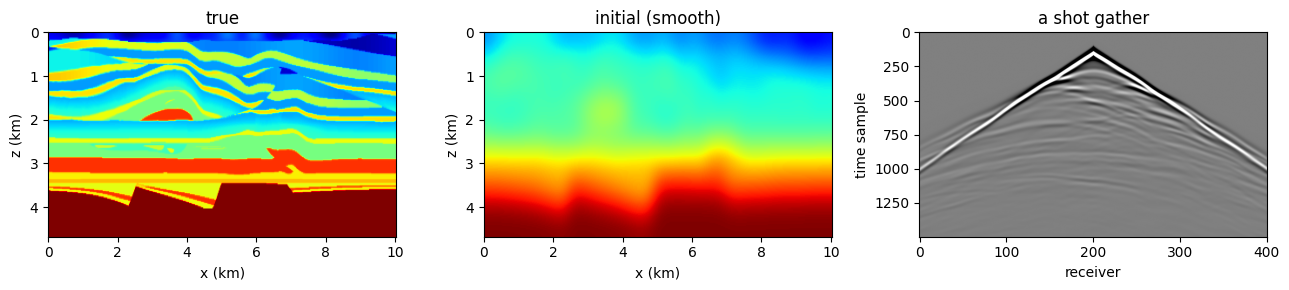

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3))
ext = [0, nx*DH/1000, nz*DH/1000, 0]
vk = dict(cmap="jet", aspect="auto", extent=ext, vmin=vp_true.min(), vmax=vp_true.max())
for a, m, t in zip(ax[:2], [vp_true, vp_smooth], ["true", "initial (smooth)"]):
    a.imshow(m, **vk); a.set_title(t); a.set_xlabel("x (km)"); a.set_ylabel("z (km)")
g = observed[len(sources)//2, :, :, 0].detach().cpu().numpy()
v = np.percentile(np.abs(g), 98)
ax[2].imshow(g, cmap="gray", aspect="auto", vmin=-v, vmax=v)
ax[2].set_title("a shot gather"); ax[2].set_xlabel("receiver"); ax[2].set_ylabel("time sample")
plt.tight_layout(); plt.show()

In [5]:
print("Experiment 1/3 - conventional FWI (optimize grid velocity directly)")
h_conv = F.run_cached(
    f"../figures/cache_{TAG}_conv.npz",
    lambda: F.conventional_fwi(solver, wavelet, sources, receivers, observed, vp_smooth_t,
                               epochs=CONV_EPOCHS, lr=CONV_LR, batch=BATCH, true_vp=vp_true),
    signature=(SPATIAL_ORDER, ABCN, CONV_EPOCHS, CONV_LR, BATCH))

Experiment 1/3 - conventional FWI (optimize grid velocity directly)
  [cache] loaded cache_overthrust_conv.npz (delete it to recompute)


In [6]:
print("Experiment 2/3 - implicit FWI (SIREN reparameterization)")
def _run_ifwi():
    torch.manual_seed(F.SEED)
    net2 = F.VelocityNet(shape, std=STD2, mean=0.0, hidden=HIDDEN, layers=LAYERS2,
                         omega=OMEGA, device=dev)
    return F.implicit_fwi(solver, wavelet, sources, receivers, observed, vp_smooth_t, net2,
                          epochs=EPOCHS, lr=NN_LR, lr_decay=LR_DECAY, batch=BATCH, true_vp=vp_true)
h_ifwi = F.run_cached(f"../figures/cache_{TAG}_ifwi.npz", _run_ifwi,
    signature=(SPATIAL_ORDER, ABCN, EPOCHS, STD2, LAYERS2, OMEGA, HIDDEN, NN_LR, LR_DECAY, BATCH))

Experiment 2/3 - implicit FWI (SIREN reparameterization)
  [cache] loaded cache_overthrust_ifwi.npz (delete it to recompute)


In [7]:
print("Experiment 3/3 -", EXP3_TITLE)
def _run_exp3():
    torch.manual_seed(F.SEED)
    net3 = F.VelocityNet(shape, std=STD3, mean=0.0, hidden=HIDDEN, layers=LAYERS3,
                         omega=OMEGA, hash_cfg=HASH_CFG, device=dev)
    return F.implicit_fwi(solver, wavelet, sources, receivers, observed, vp_smooth_t, net3,
                          use_ph=USE_PH, grad_clip_q=GRAD_CLIP_Q, epochs=EPOCHS, lr=NN_LR,
                          lr_decay=LR_DECAY, batch=BATCH, true_vp=vp_true)
h3 = F.run_cached(f"../figures/cache_{TAG}_exp3.npz", _run_exp3,
    signature=(SPATIAL_ORDER, ABCN, EPOCHS, STD3, LAYERS3, OMEGA, HIDDEN, str(HASH_CFG), USE_PH, GRAD_CLIP_Q, NN_LR, LR_DECAY, BATCH))

Experiment 3/3 - implicit FWI + pseudo-Hessian (energy-weighted gradient)
  [cache] loaded cache_overthrust_exp3.npz (delete it to recompute)


## Comparison of the three inversions

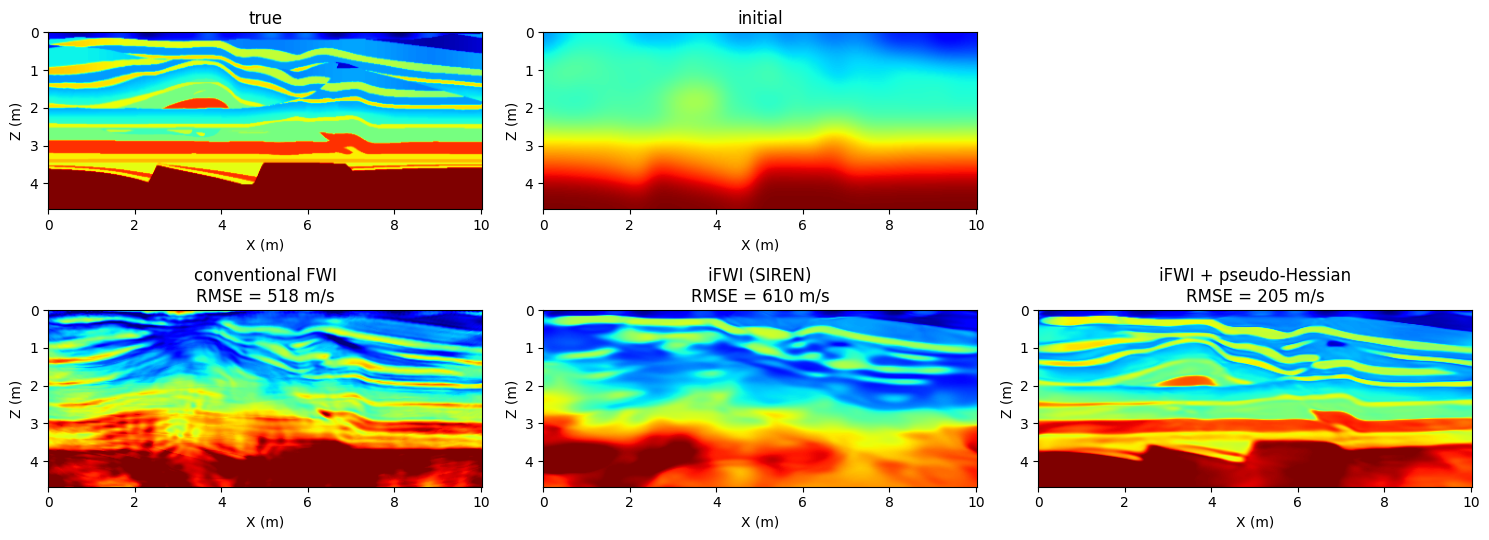

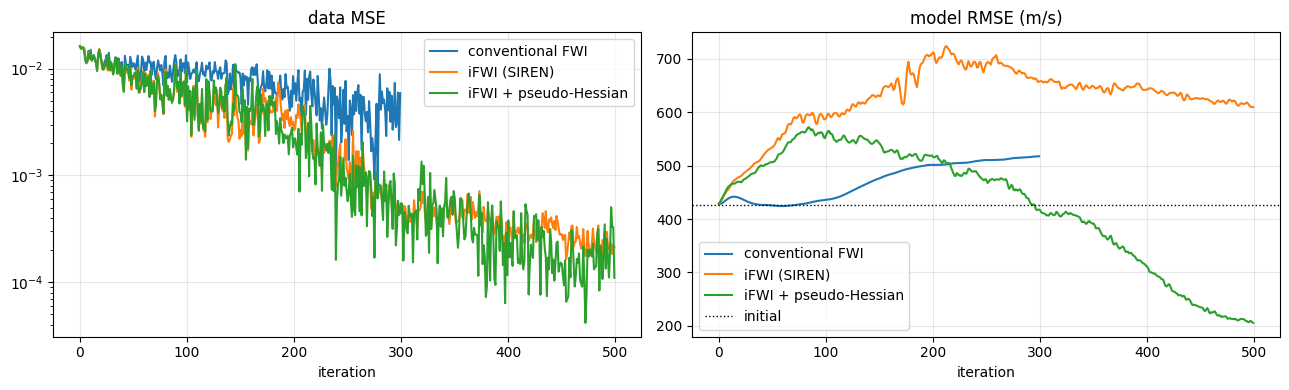

final model RMSE (m/s): {'conventional FWI': 518, 'iFWI (SIREN)': 610, 'iFWI + pseudo-Hessian': 205}


In [8]:
runs = [("conventional FWI", h_conv), ("iFWI (SIREN)", h_ifwi), (EXP3_LABEL, h3)]
rmse = lambda a: float(np.sqrt(np.mean((a - vp_true) ** 2)))
rms_true = float(np.sqrt(np.mean(vp_true ** 2)))
ext = [0, nx*DH/1000, nz*DH/1000, 0]
vk = dict(cmap="jet", aspect="auto", extent=ext, vmin=vp_true.min(), vmax=vp_true.max())

fig, axes = plt.subplots(2, 3, figsize=(15, 5.5))
for a, (name, m) in zip(axes[0], [("true", vp_true), ("initial", vp_smooth)]):   # row 1: true + initial
    a.imshow(m, **vk); a.set_title(name); a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
axes[0, 2].axis("off")
for a, (name, h) in zip(axes[1], runs):                                          # row 2: the three inversions
    r = rmse(h["vp"])
    a.imshow(np.nan_to_num(h["vp"], nan=float(vp_true.mean())), **vk)
    a.set_title(f"{name}\nRMSE = {r:.0f} m/s" if np.isfinite(r) else f"{name}\n(diverged)")
    a.set_xlabel("X (m)"); a.set_ylabel("Z (m)")
plt.tight_layout(); plt.savefig(f"../figures/{TAG}_models.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, h in runs:
    ax[0].semilogy(h["loss"], label=name)
    ax[1].plot(np.array(h["rel"]) * rms_true, label=name)
ax[1].axhline(rmse(vp_smooth), color="k", ls=":", lw=1, label="initial")
ax[0].set_title("data MSE"); ax[0].set_xlabel("iteration"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_title("model RMSE (m/s)"); ax[1].set_xlabel("iteration"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"../figures/{TAG}_curves.png", dpi=150, bbox_inches="tight"); plt.show()

print("final model RMSE (m/s):", {name: (round(rmse(h["vp"])) if np.isfinite(rmse(h["vp"])) else "NaN") for name, h in runs})